In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
graphs = ['as-733-complete']
functions = ['intersection']#, 'union_half']
results_folder = "."

In [4]:
for graph in graphs:
    for func in functions:
        filename = results_folder + "/" + "results_" + graph + "_" + func + ".csv"
        df = pd.read_csv(filename)
        df['msg_per_iter'] = pd.DataFrame(df['msg_per_iter'].apply(eval))['msg_per_iter'].apply(np.array)
        df['time_per_iter'] = pd.DataFrame(df['time_per_iter'].apply(eval))['time_per_iter'].apply(np.array)
        # Calculate the average of msg_per_iter for each row
        df['avg_msg_per_iter'] = df['msg_per_iter'].apply(np.mean)

        # Exclude the first 4 rows
        for mem_size in df['mem_size'].unique():
            temp_df = df[df['mem_size'] == mem_size]
            df_filtered = temp_df.iloc[(mem_size-1):]
            x_labels = [f"{i}-{i+mem_size}" for i in range(len(df_filtered))]

            # CLASSIC MONTRESOR DATA
            filename_old = results_folder + "/" + "full_results_" + graph + "_" + func + ".csv"
            df_old = pd.read_csv(filename_old)
            df_old['msg_per_iter'] = pd.DataFrame(df_old['msg_per_iter'].apply(eval))['msg_per_iter'].apply(np.array)
            df_old['time_per_iter'] = pd.DataFrame(df_old['time_per_iter'].apply(eval))['time_per_iter'].apply(np.array)
            # Calculate the average of msg_per_iter for each row
            df_old['avg_msg_per_iter'] = df_old['msg_per_iter'].apply(np.mean)

            # Exclude the first 4 rows
            temp_df_old = df_old[df_old['mem_size'] == mem_size]
            df_filtered_old = temp_df_old.copy() #.iloc[(mem_size-1):]
            x_labels_old = [f"{i}-{i+mem_size}" for i in range(len(df_filtered_old))]

            # Calculate the percentage of activated nodes relative to total nodes
            df_filtered = df_filtered.copy()
            df_filtered['relative_activ_nodes'] = df_filtered['activated_nodes'] / df_filtered['nodes'] * 100
            
            df_filtered_old = df_filtered_old.copy()
            df_filtered_old['relative_activ_nodes'] = df_filtered_old['activated_nodes'] / df_filtered_old['nodes'] * 100

            # Create a line plot for the number of iters
            plt.figure(figsize=(18, 10))
            plt.xlabel('Iterations Range')
            plt.ylabel('Number of Iterations')
            plt.title(f'Average Number of Iterations per Window (memory size: {df["mem_size"][0]}, function: {func}, memory size: {mem_size})')
            plt.xticks(rotation=90)

            sns.lineplot(x=x_labels, y='iters', data=df_filtered, marker='o', label="Dynamic Montresor")
            sns.lineplot(x=x_labels_old, y='iters', data=df_filtered_old, marker='x', label="Classic Montresor")
            plt.legend()
            plt.show()

            # Create a new figure for the relative activated nodes
            plt.figure(figsize=(18, 10))
            plt.xlabel('Iterations Range')
            plt.ylabel('Relative Activated Nodes (%)')
            plt.title(f'Percentage of activated nodes per Window (memory size: {df["mem_size"][0]}, function: {func}, memory size: {mem_size})')
            
            
            plt.xticks(rotation=90)

            sns.lineplot(x=x_labels, y='relative_activ_nodes', data=df_filtered, marker='o', label="Dynamic Montresor - Activated Nodes")
            sns.lineplot(x=x_labels_old, y='relative_activ_nodes', data=df_filtered_old, marker='x', label="Classic Montresor - Activated Nodes")

            plt.legend()
            plt.show()

            # Create a new figure for the total messages
            plt.figure(figsize=(18, 10))
            plt.xlabel('Iterations Range')
            plt.ylabel('Total Messages')
            plt.title(f'Total Messages per Window (memory size: {df["mem_size"][0]}, function: {func}, memory size: {mem_size})')
            plt.xticks(rotation=90)

            sns.lineplot(x=x_labels, y='total_msg', data=df_filtered, marker='o', label="Dynamic Montresor - Total Messages")
            sns.lineplot(x=x_labels_old, y='total_msg', data=df_filtered_old, marker='x', label="Classic Montresor - Total Messages")

            plt.legend()
            plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './results_as-733-complete_intersection.csv'

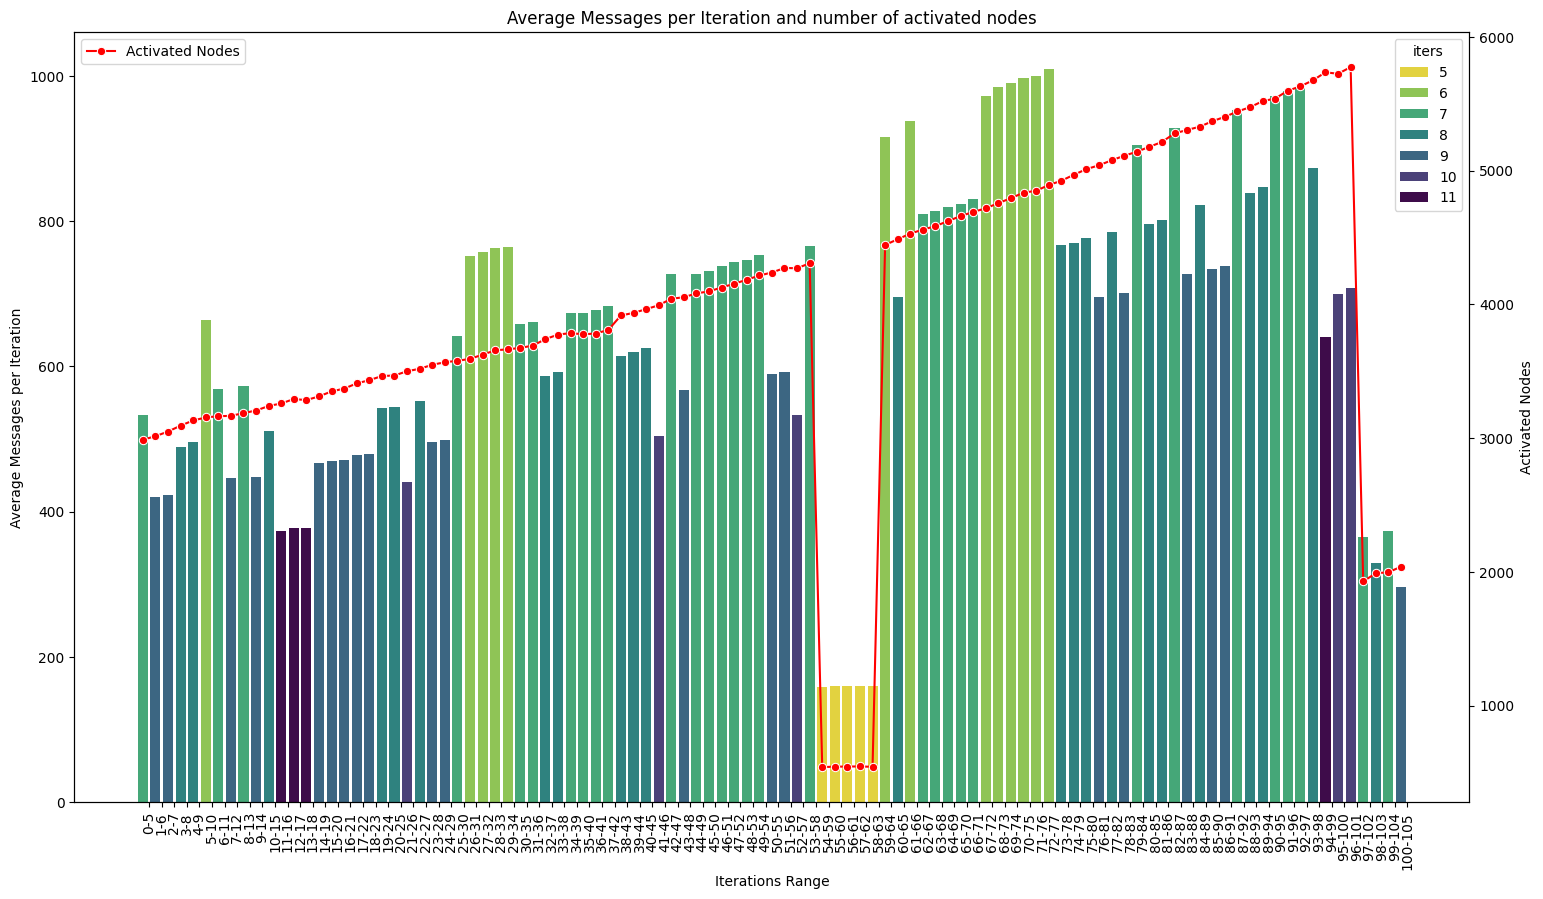

In [ ]:



for graph in graphs:
    for func in functions: 
        filename = results_folder + "/" + "results_" + graph + "_" + func + ".csv"
        df = pd.read_csv(filename)
        df['msg_per_iter'] = pd.DataFrame(df['msg_per_iter'].apply(eval))['msg_per_iter'].apply(np.array)
        df['time_per_iter'] = pd.DataFrame(df['time_per_iter'].apply(eval))['time_per_iter'].apply(np.array)
        # Calculate the average of msg_per_iter for each row
        df['avg_msg_per_iter'] = df['msg_per_iter'].apply(np.mean)


        for mem_size, group in df.groupby('mem_size'):
            print(f"Processing memory size: {mem_size}")
            # Exclude the first 4 rows
            df_filtered = df.iloc[(mem_size-1):]

        # Create x labels
        x_labels = [f"{i}-{i+5}" for i in range(len(df_filtered))]

        # Create a bar plot
        plt.figure(figsize=(18, 10))
        sns.barplot(x=x_labels, y='avg_msg_per_iter', hue='iters', data=df_filtered, palette='viridis_r')
        plt.xlabel('Iterations Range')
        plt.ylabel('Average Messages per Iteration')
        plt.title('Average Messages per Iteration ')
        plt.xticks(rotation=90)

        # Add a line plot for activated_nodes
        ax2 = plt.gca().twinx()
        sns.lineplot(x=x_labels, y='activated_nodes', data=df_filtered, ax=ax2, color='red', marker='o')
        ax2.set_ylabel('Activated Nodes')
        ax2.legend(['Activated Nodes'], loc='upper left')
        #ax2.set_yscale("log")

        # Add some space between the bars and the corresponding x labels
        ax1 = plt.gca()
        ax1.set_xticks(np.arange(len(x_labels)) + 0.5)
        ax1.set_xticklabels(x_labels, rotation=90, ha='right')

        # Separate each bar with some space
        for bar in ax1.patches:
            bar.set_width(bar.get_width() * 0.8)
            bar.set_x(bar.get_x() + bar.get_width() * 0.1)

        plt.show()



        
        


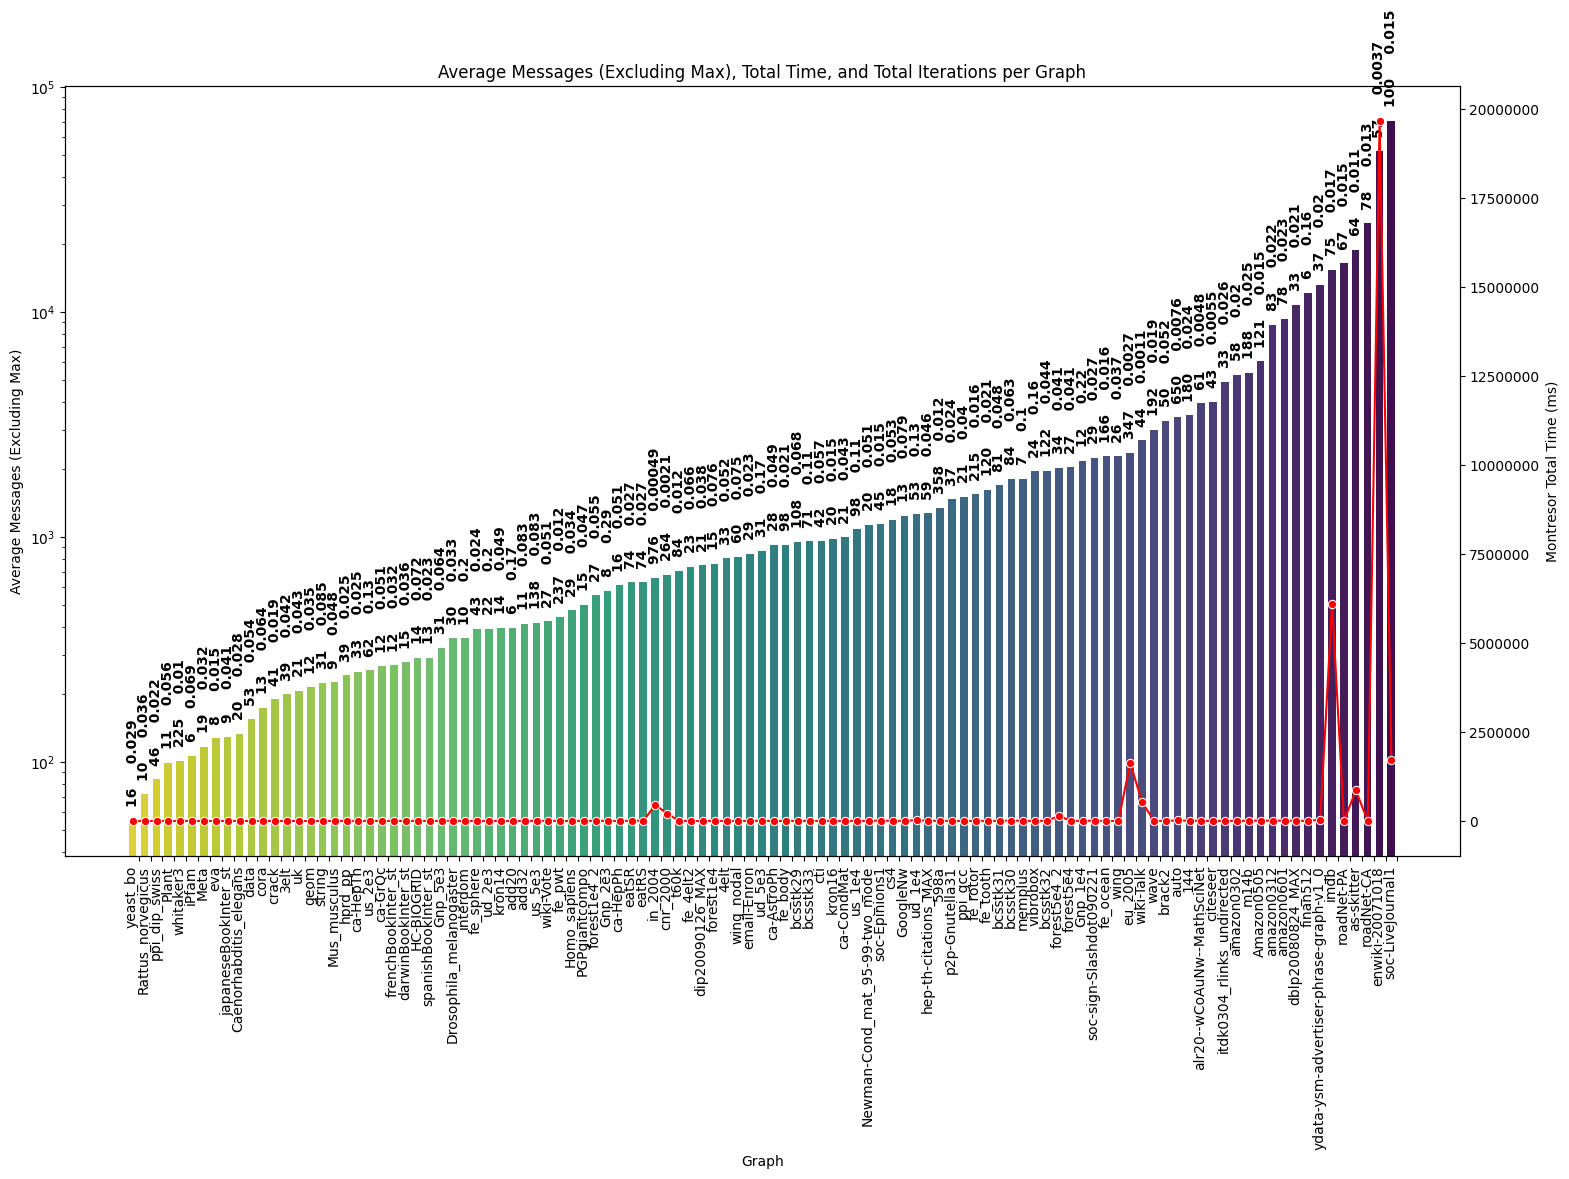

In [24]:
# Calculate the average of 'msgs' excluding the maximum value for each row
df['avg_msgs_ex_max'] = df['msgs'].apply(lambda x: np.mean(np.delete(x, np.argmax(x))))

# Remove rows with n < 1500
df_filtered = df[df['n'] >= 1500]

# Sort the filtered dataframe by 'avg_msgs_ex_max'
df_sorted = df_filtered.sort_values(by='avg_msgs_ex_max')

# Create a bar plot for the average of 'msgs' excluding the maximum value
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(x='Graph', y='avg_msgs_ex_max', hue='Graph', data=df_sorted, ax=ax1, palette='viridis_r', legend=False)
ax1.set_yscale('log')
ax1.set_ylabel('Average Messages (Excluding Max)')
ax1.set_xlabel('Graph')
ax1.tick_params(axis='x', rotation=90)  # Correctly rotate x-axis tick labels

# Create a second y-axis for 'montresor_total_time'
ax2 = ax1.twinx()
sns.lineplot(x='Graph', y='montresor_total_time', data=df_sorted, ax=ax2, color='red', marker='o')
ax2.set_yscale('linear')
ax2.set_ylabel('Montresor Total Time (ms)')
ax2.ticklabel_format(style='plain', axis='y')
# Separate each bar with some space
for bar in ax1.patches:
    bar.set_width(bar.get_width() * 0.8)
    bar.set_x(bar.get_x() + bar.get_width() * 0.1)

# Adjust the x-axis to add some space between the bars
ax1.set_xticks(np.arange(len(df_sorted)) + 0.5)
ax1.set_xticklabels(df_sorted['Graph'], rotation=90, ha='right')

# Resize the figure to make x labels readable
fig.set_size_inches(18, 10)

# Add a vertical label on top of each bar showing the corresponding 'montresor_iters'
for i, bar in enumerate(ax1.patches):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar.get_height() * 0.15,  # Adjust the height to place the text a little higher based on the bar height
        f'{df_sorted.iloc[i]["montresor_iters"]}     {df_sorted.iloc[i]["avg_msgs_ex_max"] / df_sorted.iloc[i]["n"]:.2}',  # Add the result of 'msgs' divided by 'n'
        ha='center',
        va='bottom',
        rotation=90,
        fontweight='bold'  # Make the font bold
    )

plt.title('Average Messages (Excluding Max), Total Time, and Total Iterations per Graph')
plt.show()


# Aggiungere numero di iterazioni -- ok
# il numero di iterazioni può essere minore (fornisce un'approssimazione)
# cioè ci si può fermare dopo x iterazioni e vedere cosa abbiamo ottenuto rispetto alla ground truth
# analisi numero di messaggi rispetto a nodi/archi/degree

In [6]:
file_temporal = "results_temporal.csv"
df_temporal = pd.read_csv(file_temporal)
df_temporal['msgs'] = pd.DataFrame(df_temporal['msgs'].apply(eval))['msgs'].apply(np.array)
df_temporal['msgs'] 

0         [4424, 772, 225, 80, 29, 11, 7, 13, 2, 1, 2]
1                               [455, 133, 39, 12, 11]
2         [4424, 772, 225, 80, 29, 11, 7, 13, 2, 1, 2]
3           [7716, 1536, 635, 291, 140, 72, 26, 19, 1]
4                      [424, 74, 16, 8, 1, 1, 4, 5, 2]
5                                                  [2]
6                      [424, 74, 16, 8, 1, 1, 4, 5, 2]
7    [54075, 17248, 7791, 3693, 2012, 1167, 778, 55...
Name: msgs, dtype: object

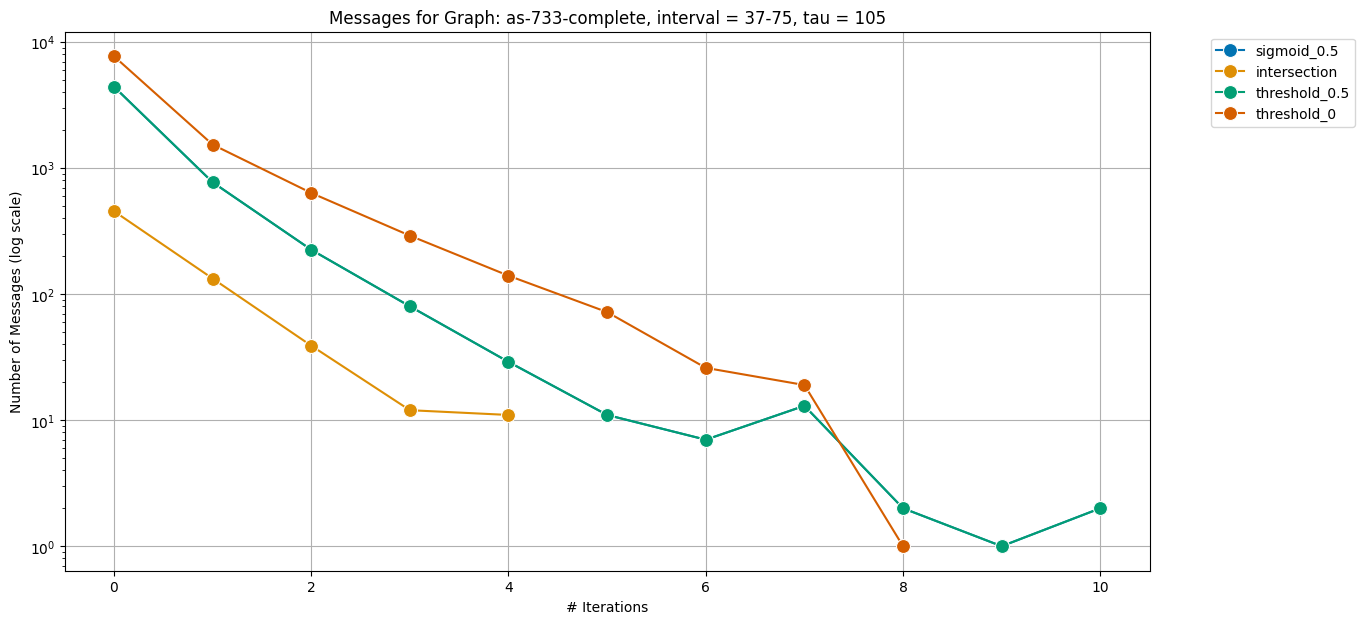

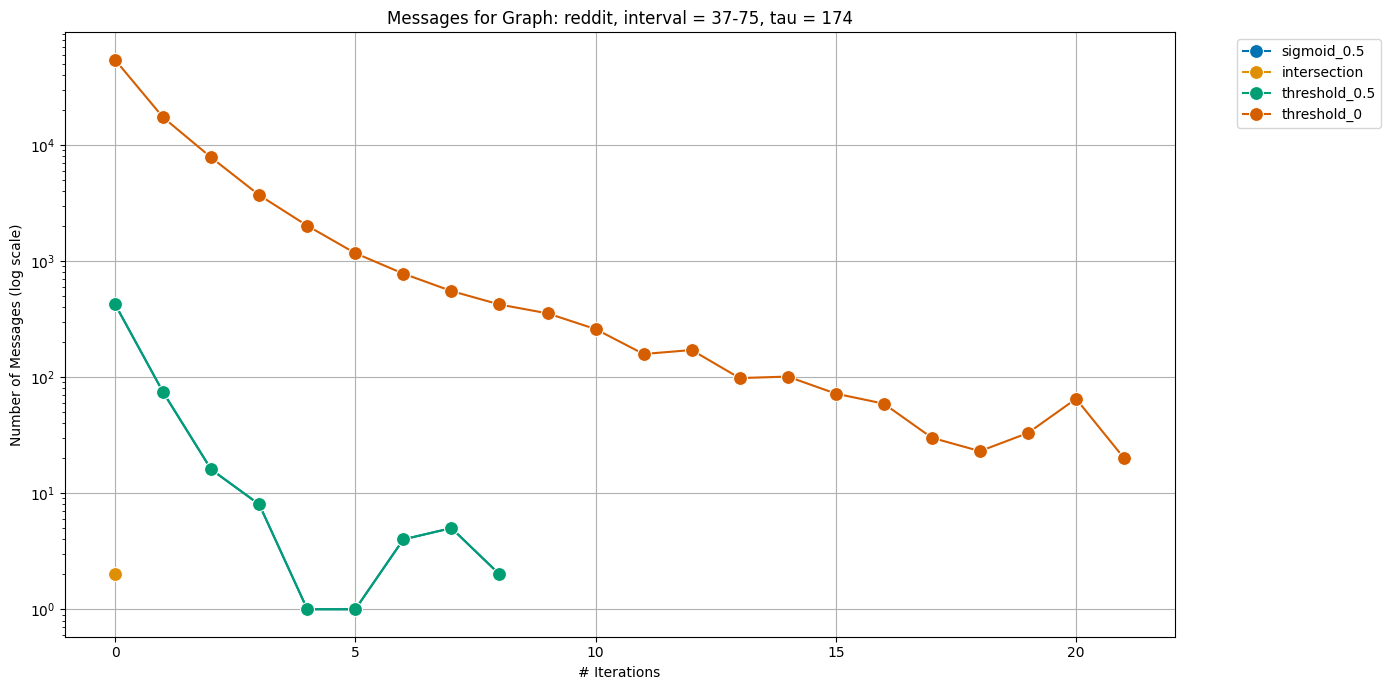

In [26]:
sns.set_palette("colorblind")

# Iterate over each unique graph
for graph in df_temporal['Graph'].unique():
    plt.figure(figsize=(14, 7))
    plt.grid(True)

    # Subset the dataframe for the current graph
    subset = df_temporal[df_temporal['Graph'] == graph]
    
    # Iterate over each unique function within the current graph
    for function in subset['function'].unique():
        function_subset = subset[subset['function'] == function]
        for _, row in function_subset.iterrows():
            sns.lineplot(data=row['msgs'], label=f"{function}", marker='o', markersize=10)

    plt.xlabel('# Iterations')
    plt.ylabel('Number of Messages (log scale)')
    plt.title(f'Messages for Graph: {graph}, interval = {subset["a"].iloc[0]}-{subset["b"].iloc[0]}, tau = {subset["snaps"].iloc[0]}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.yscale("log")


plt.tight_layout()
plt.show()